In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [4]:
# Загрузка данных
df = pd.read_csv("absolute_score.csv")

# --- 1. Приведение числовых колонок ---
numeric_cols = ["QED", "SA", "MW", "logP"]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

In [5]:
# --- 2. Приведение бинарных колонок ---
binary_cols = ["Lipinski", "BRENK", "PAINS", "Glaxo"]

for col in binary_cols:
    df[col] = df[col].astype(bool)

C:\Users\yarat\AppData\Local\Temp\ipykernel_21484\991647066.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




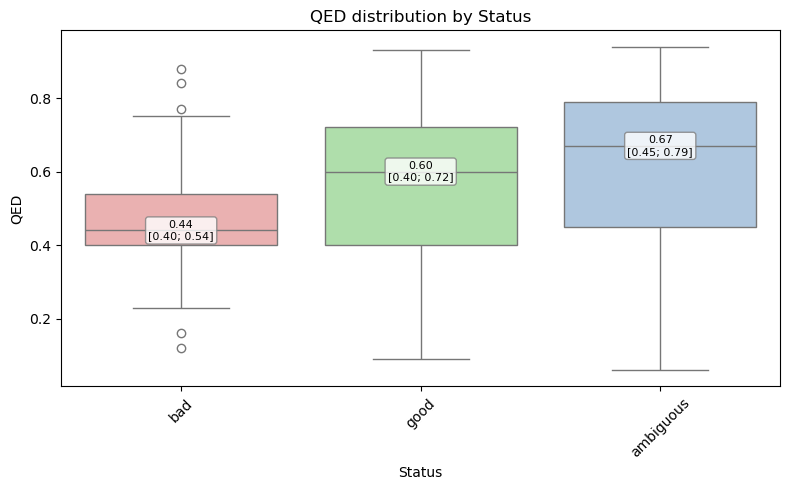

C:\Users\yarat\AppData\Local\Temp\ipykernel_21484\991647066.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




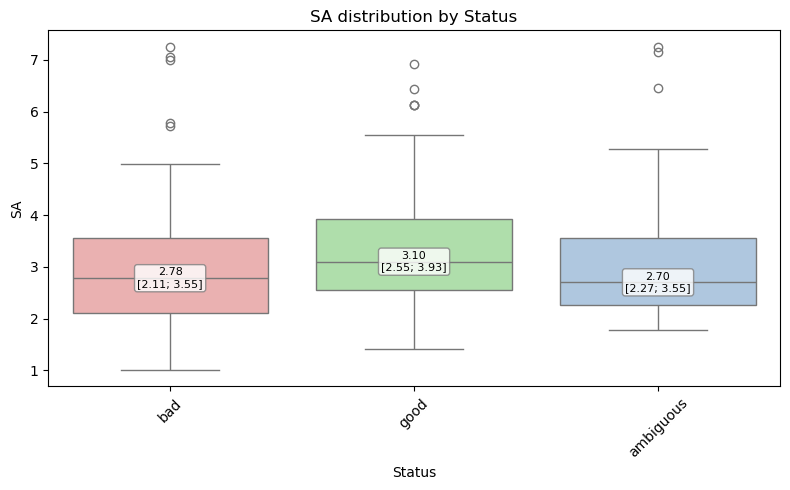

C:\Users\yarat\AppData\Local\Temp\ipykernel_21484\991647066.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




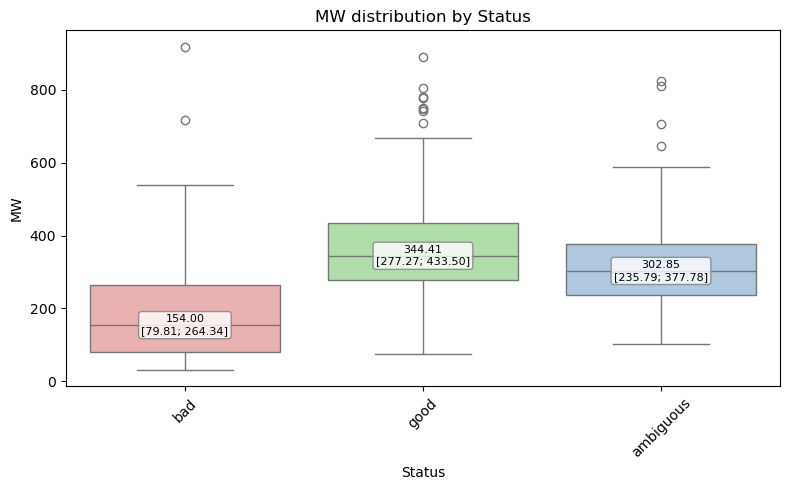

C:\Users\yarat\AppData\Local\Temp\ipykernel_21484\991647066.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




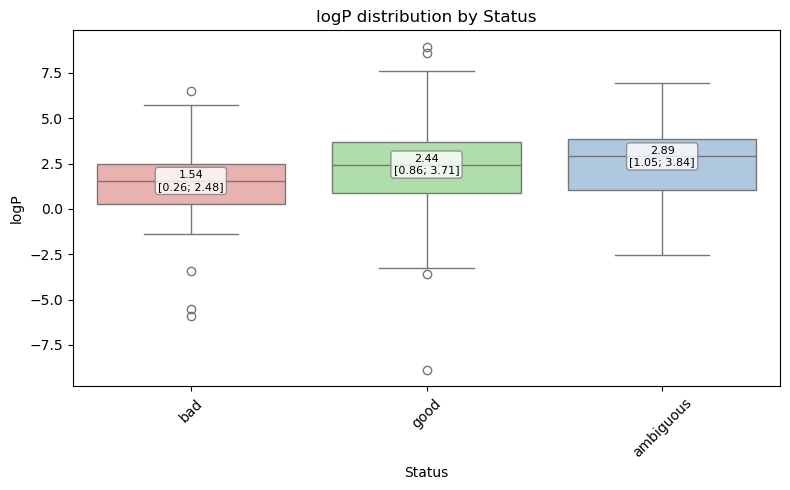

In [21]:
# Выбор категории (можешь поменять на "Status_Reason")
category_col = "Status"


palette = {
    "bad": "#F4A7A7",
    "good": "#A8E6A3",
    "ambiguous": "#A7C7E7"
}

for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    
    ax = sns.boxplot(
        data=df,
        x="Status",
        y=col,
        palette=palette
    )

    # правильный порядок категорий (как на графике)
    categories = [t.get_text() for t in ax.get_xticklabels()]

    for i, cat in enumerate(categories):
        subset = df[df["Status"] == cat][col].dropna()

        if len(subset) == 0:
            continue

        q1 = subset.quantile(0.25)
        median = subset.quantile(0.5)
        q3 = subset.quantile(0.75)

        # позиция чуть выше медианы
        y = median

        ax.text(
            i,
            y,
            f"{median:.2f}\n[{q1:.2f}; {q3:.2f}]",
            ha="center",
            va="center",
            fontsize=8,
            bbox=dict(
                boxstyle="round,pad=0.25",
                fc="white",
                ec="gray",
                alpha=0.8
            )
        )

    plt.title(f"{col} distribution by Status")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

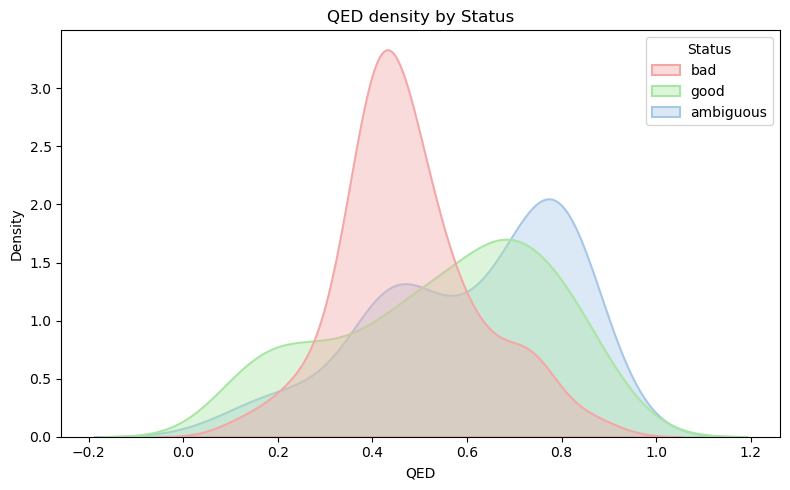

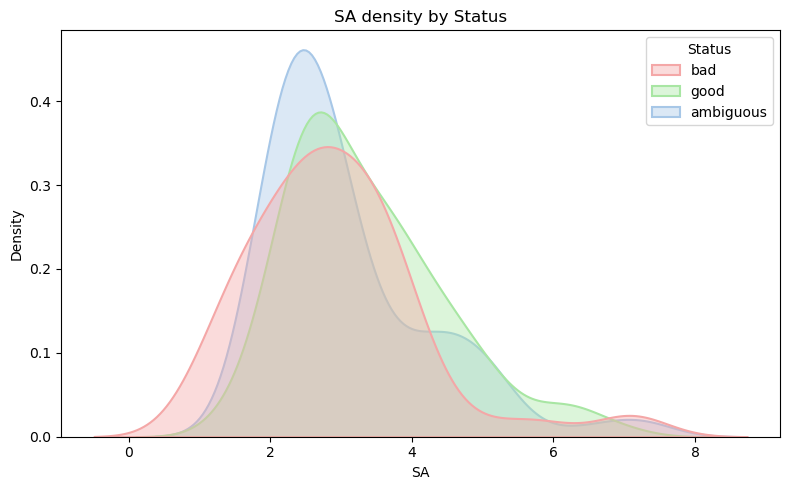

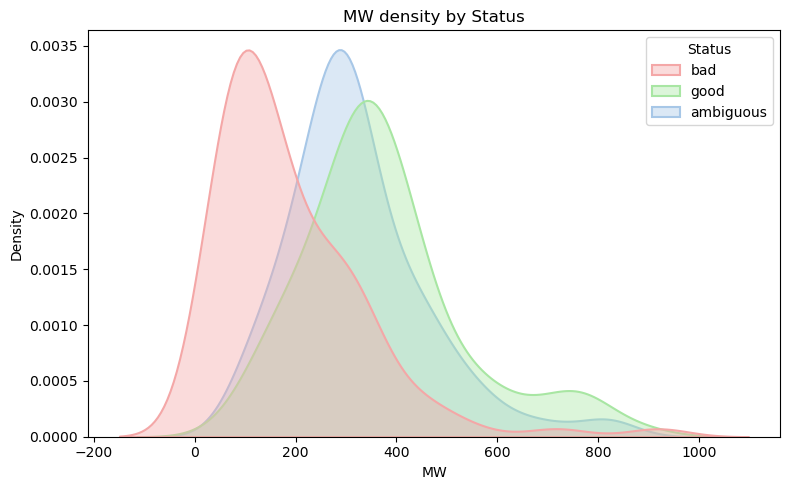

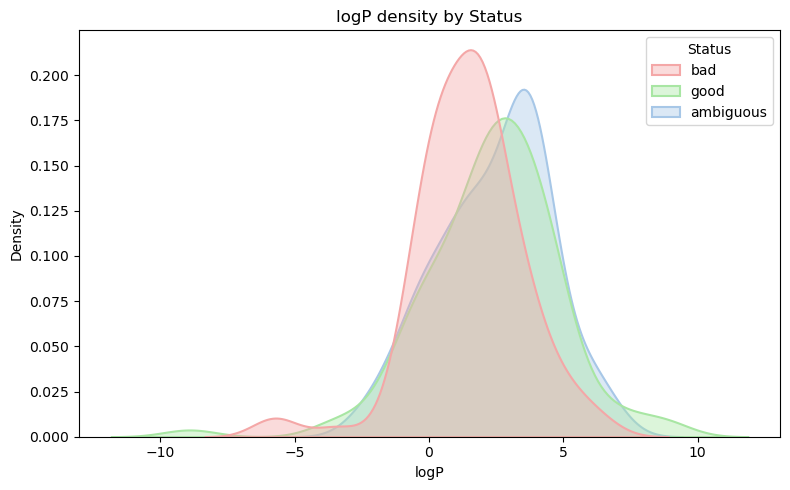

In [25]:
# =========================
# 📊 2. ГИСТОГРАММЫ
# =========================
for col in numeric_cols:
    plt.figure(figsize=(8, 5))

    sns.kdeplot(
        data=df,
        x=col,
        hue=category_col,
        palette=palette,
        fill=True,          # мягкая заливка
        common_norm=False,  # не смешиваем распределения
        alpha=0.4,
        linewidth=1.5
    )

    plt.title(f"{col} density by {category_col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

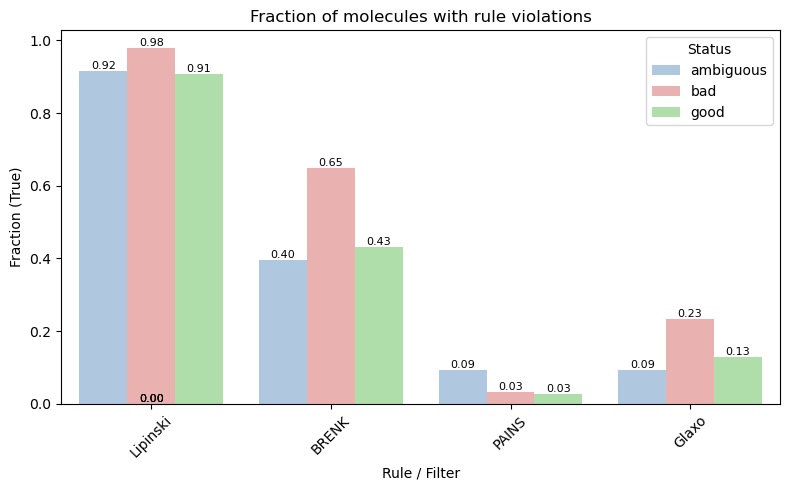

In [33]:
# =========================
# 📊 3. БИНАРНЫЕ ПРИЗНАКИ
# =========================
# считаем долю True по категориям
binary_summary = df.groupby(category_col)[binary_cols].mean().reset_index()

# переводим в "длинный" формат
binary_melted = binary_summary.melt(
    id_vars=category_col,
    var_name="Feature",
    value_name="Fraction True"
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=binary_melted,
    x="Feature",
    y="Fraction True",
    hue=category_col,
    palette=palette
)

# подписи на столбцах
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.title("Fraction of molecules with rule violations")
plt.ylabel("Fraction (True)")
plt.xlabel("Rule / Filter")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

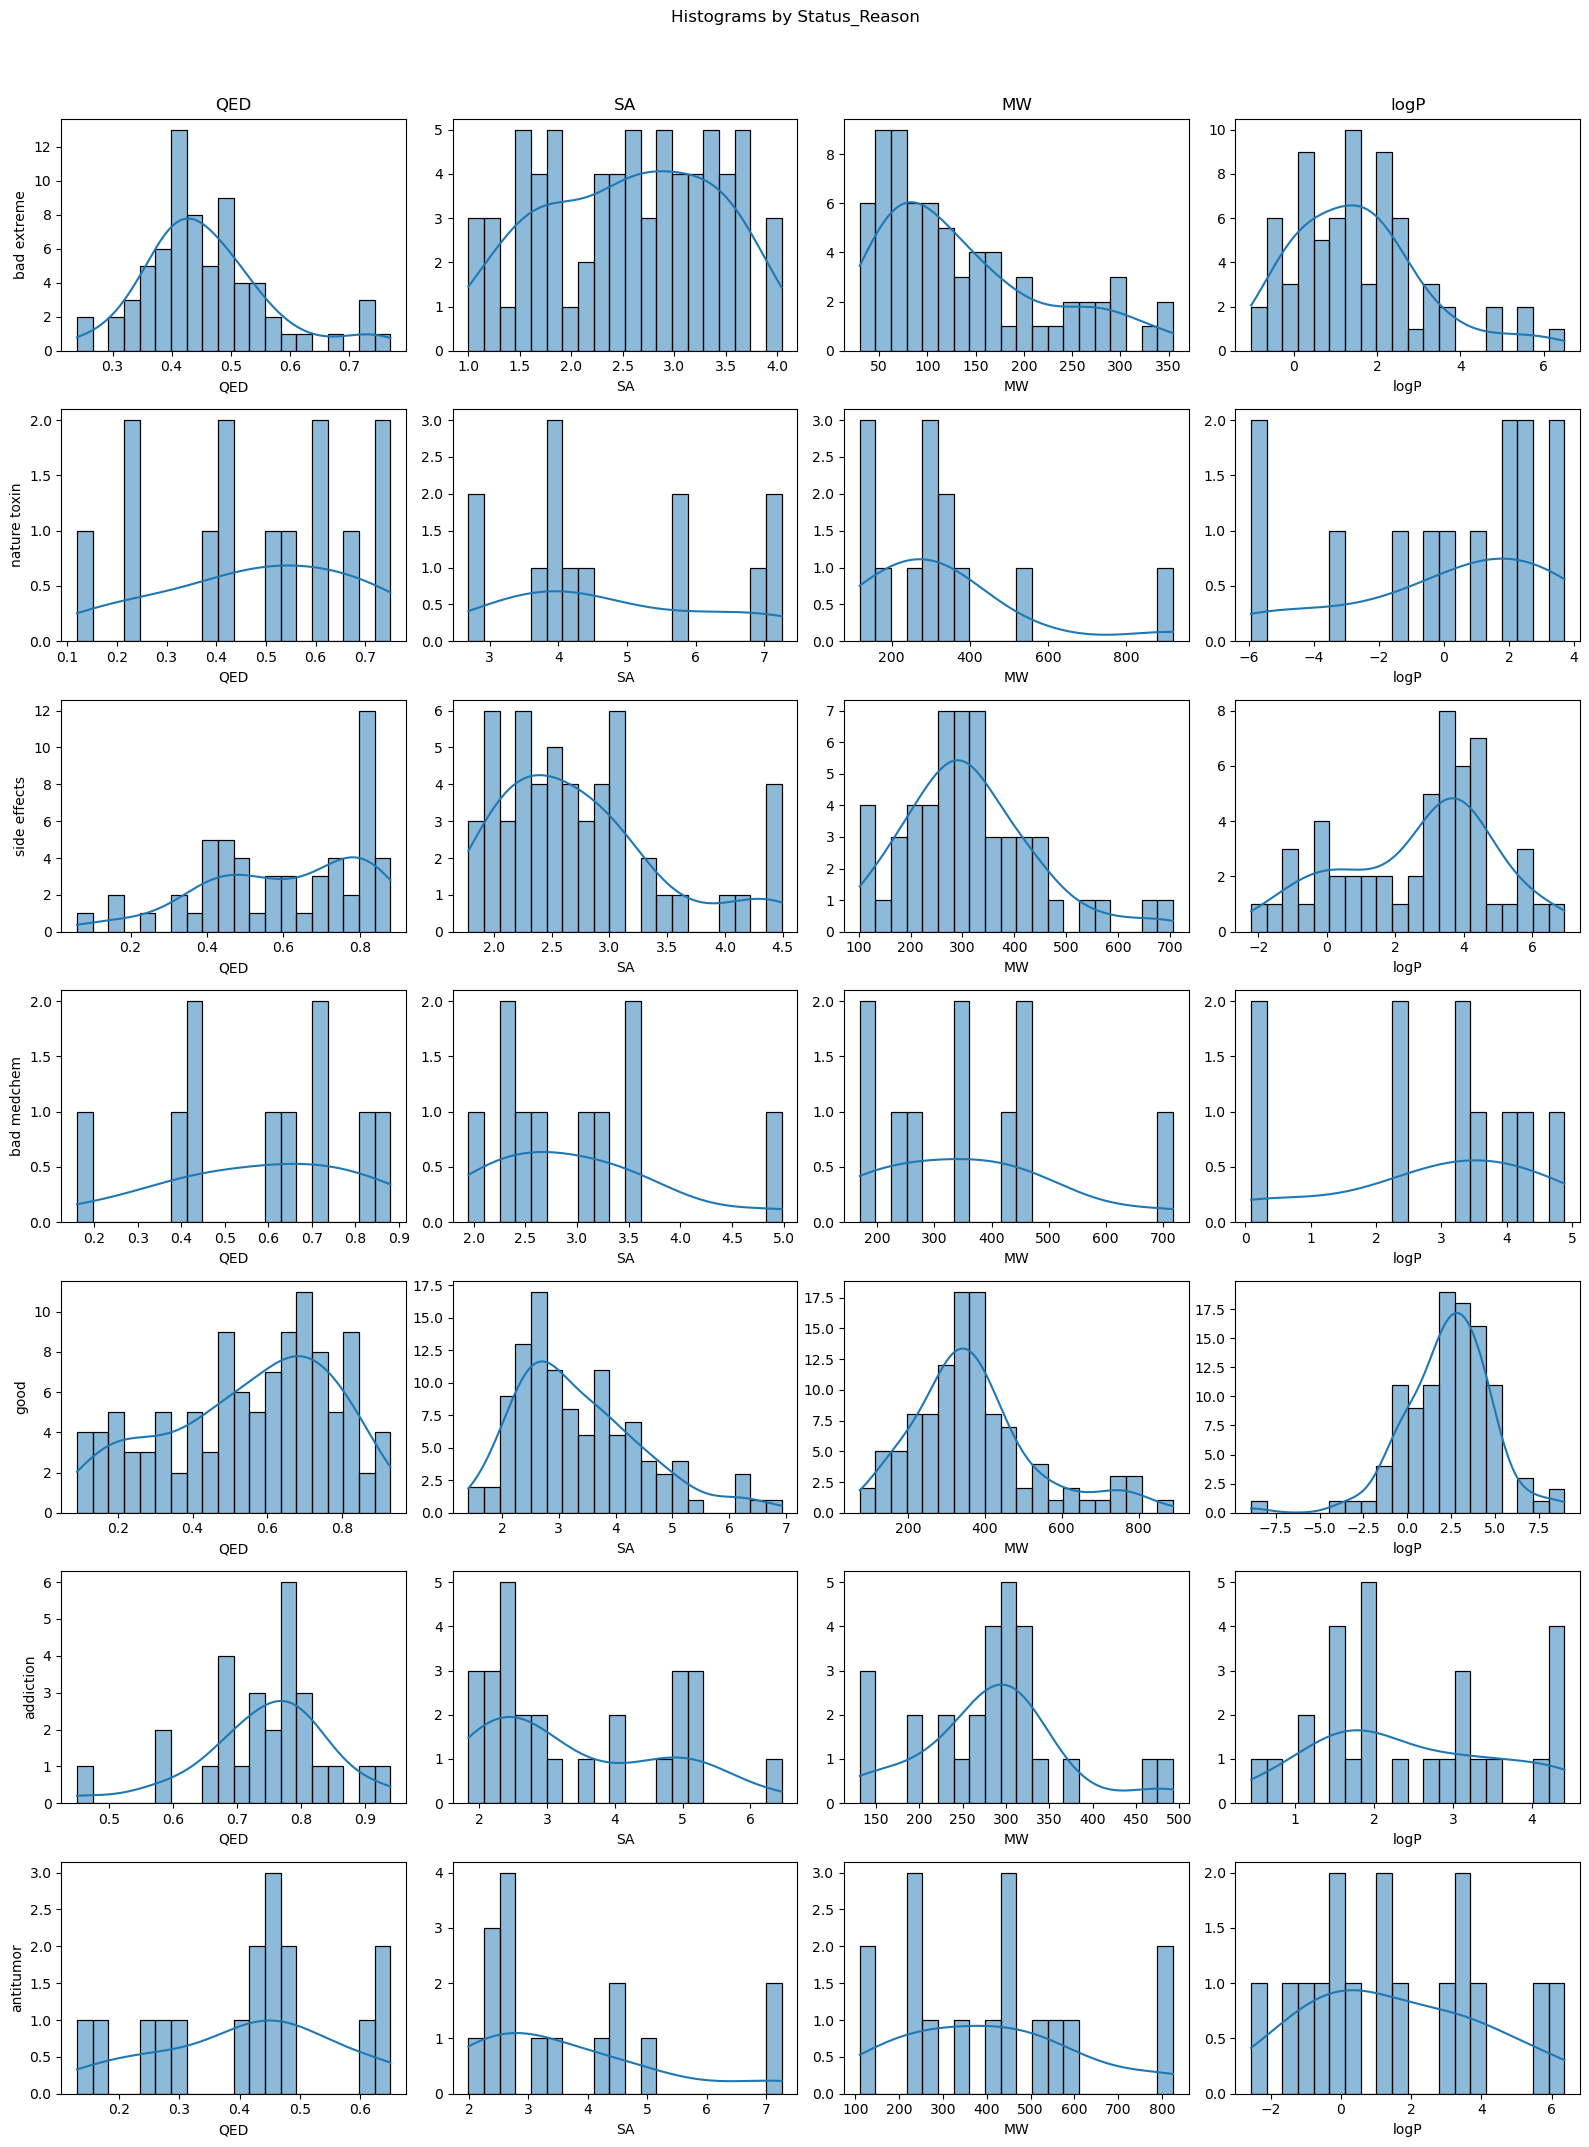

In [35]:
category_col = "Status_Reason"

# категории
categories = df[category_col].dropna().unique()

n_rows = len(categories)
n_cols = len(numeric_cols)


# =========================================
# 📊 1. СЕТКА ГИСТОГРАММ
# =========================================
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows), squeeze=False)

for i, cat in enumerate(categories):
    subset = df[df[category_col] == cat]

    for j, col in enumerate(numeric_cols):
        ax = axes[i, j]

        sns.histplot(
            data=subset,
            x=col,
            bins=20,
            kde=True,
            ax=ax
        )

        if i == 0:
            ax.set_title(col)

        if j == 0:
            ax.set_ylabel(cat)
        else:
            ax.set_ylabel("")

plt.suptitle("Histograms by Status_Reason", y=1.02)
plt.tight_layout()
plt.show()


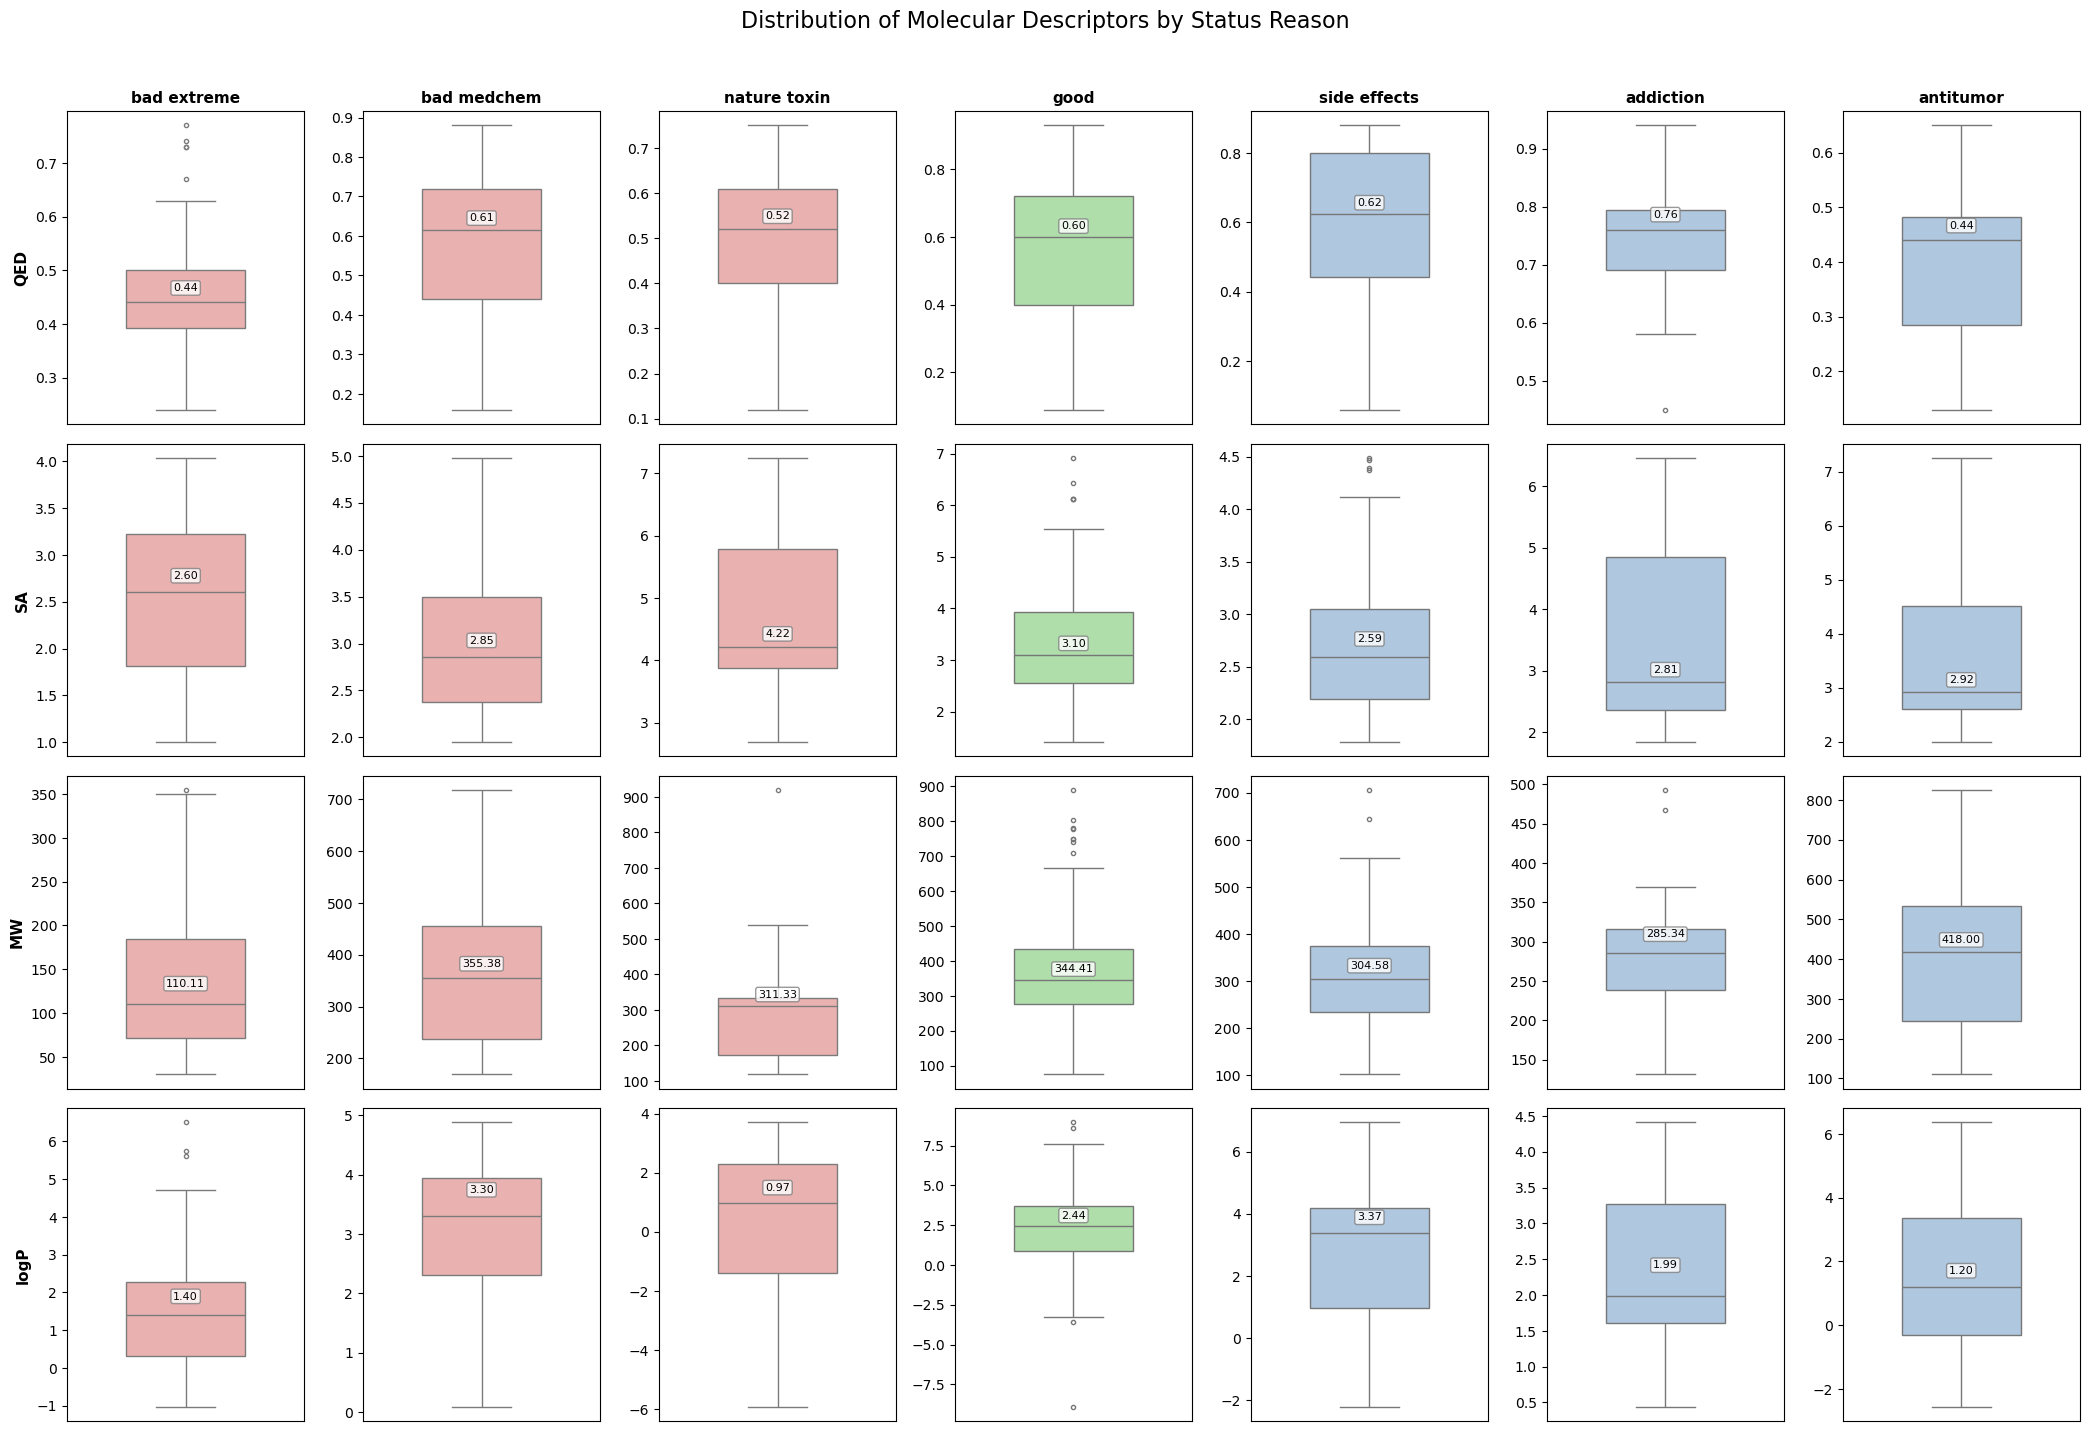

In [12]:
category_col = "Status_Reason"
# порядок категорий слева направо
ordered_categories = [
    "bad extreme",
    "bad medchem",
    "nature toxin",
    "good",
    "side effects",
    "addiction",
    "antitumor"
]

# цветовая схема
color_map = {
    "bad extreme": "#F4A7A7",
    "bad medchem": "#F4A7A7",
    "nature toxin": "#F4A7A7",
    "good": "#A8E6A3",
    "side effects": "#A7C7E7",
    "addiction": "#A7C7E7",
    "antitumor": "#A7C7E7"
}

# оставляем только категории, присутствующие в данных
categories = [cat for cat in ordered_categories if cat in df[category_col].unique()]
plot_df = df[df[category_col].isin(categories)].copy()

# размеры сетки:
# строки    -> метрики
# столбцы   -> категории
n_rows = len(numeric_cols)
n_cols = len(categories)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3 * n_cols, 3.5 * n_rows),
    squeeze=False
)

for i, col in enumerate(numeric_cols):      # строки = метрики
    for j, cat in enumerate(categories):    # столбцы = категории
        ax = axes[i, j]

        subset = plot_df.loc[plot_df[category_col] == cat, col].dropna()

        sns.boxplot(
            y=subset,
            ax=ax,
            color=color_map.get(cat, "#D3D3D3"),
            width=0.5,
            fliersize=3
        )

        # медиана
        median = subset.median()

        if pd.notna(median):
            y_offset = 0.02 * (plot_df[col].max() - plot_df[col].min())

            ax.text(
                0,
                median + y_offset,
                f"{median:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
                bbox=dict(
                    boxstyle="round,pad=0.2",
                    fc="white",
                    ec="gray",
                    alpha=0.8
                )
            )

        # заголовки столбцов (категории)
        if i == 0:
            ax.set_title(cat, fontsize=11, fontweight="bold")

        # подписи строк (метрики)
        if j == 0:
            ax.set_ylabel(col, fontsize=11, fontweight="bold")
        else:
            ax.set_ylabel("")

        # убрать подписи по X
        ax.set_xlabel("")
        ax.set_xticks([])

plt.suptitle(
    "Distribution of Molecular Descriptors by Status Reason",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

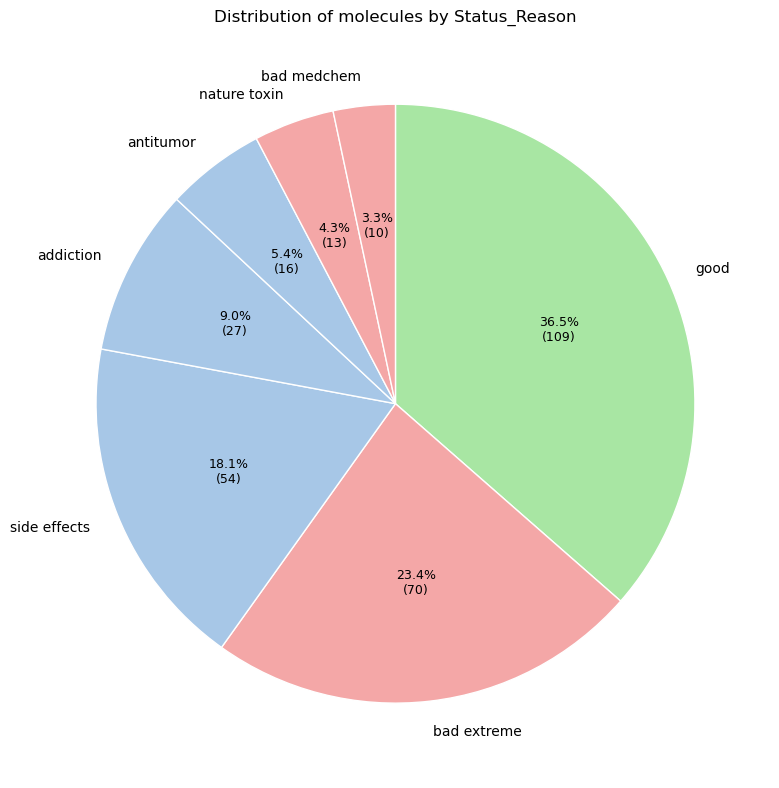

In [6]:
# Подсчёт количества молекул в каждой категории
status_counts = df["Status_Reason"].value_counts()

# Цветовая схема
color_map = {
    "bad extreme": "#F4A7A7",   # пастельный красный
    "bad medchem": "#F4A7A7",
    "nature toxin": "#F4A7A7",
    "good": "#A8E6A3",          # пастельный зелёный
    "side effects": "#A7C7E7",  # пастельный голубой
    "addiction": "#A7C7E7",
    "antitumor": "#A7C7E7"
}

# Цвета в порядке категорий
colors = [color_map.get(cat, "#D3D3D3") for cat in status_counts.index]

# Построение круговой диаграммы
plt.figure(figsize=(8, 8))

wedges, texts, autotexts = plt.pie(
    status_counts,
    labels=status_counts.index,
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct/100 * status_counts.sum()))})",
    startangle=90,
    counterclock=False,
    wedgeprops=dict(edgecolor="white", linewidth=1),
    textprops=dict(fontsize=10)
)

# Улучшение отображения процентов
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_color("black")

plt.title("Distribution of molecules by Status_Reason")
plt.tight_layout()
plt.show()